In [1]:
pip install pandas

In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import json
import os

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

#### DISREGARD

Combining snp_matrix with lineages results to 22 samples only

In [30]:
import pandas as pd
import json
import os

snp_df = pd.read_csv("snp_matrix2.csv")  

json_folder = "./results"
lineage_data = []

for sample_id in snp_df['id']:
    json_path = os.path.join(json_folder, f"{sample_id}.results.json")
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            main_lineage = data.get("main_lineage", None)
            sub_lineage = data.get("sub_lineage", None)
            lineage_data.append({
                "id": sample_id,
                "main_lineage": main_lineage,
                "sub_lineage": sub_lineage
            })
    else:
        print(f"⛔ no JSON for sample: {sample_id}")

lineage_df = pd.DataFrame(lineage_data)

filtered_snp_df = snp_df[snp_df['id'].isin(lineage_df['id'])]

merged_df = pd.merge(filtered_snp_df, lineage_df, on="id", how="inner")

merged_df.to_csv("snp_with_lineage.csv", index=False)
print("✅ final merged dataset = snp_with_lineage.csv")


⛔ no JSON for sample: ERR046840
⛔ no JSON for sample: ERR067667
⛔ no JSON for sample: ERR067745
⛔ no JSON for sample: ERR137227
⛔ no JSON for sample: ERR2184331
⛔ no JSON for sample: ERR2184364
⛔ no JSON for sample: ERR2184415
⛔ no JSON for sample: ERR2184537
⛔ no JSON for sample: ERR2184562
⛔ no JSON for sample: ERR228008
⛔ no JSON for sample: ERR229956
⛔ no JSON for sample: ERR2510337
⛔ no JSON for sample: ERR2510362
⛔ no JSON for sample: ERR2510413
⛔ no JSON for sample: ERR2510446
⛔ no JSON for sample: ERR2510531
⛔ no JSON for sample: ERR2510564
⛔ no JSON for sample: ERR2510818
⛔ no JSON for sample: ERR2512608
⛔ no JSON for sample: ERR2512780
⛔ no JSON for sample: ERR2513280
⛔ no JSON for sample: ERR2513308
⛔ no JSON for sample: ERR2513479
⛔ no JSON for sample: ERR2513486
⛔ no JSON for sample: ERR2513827
⛔ no JSON for sample: ERR2513872
⛔ no JSON for sample: ERR2514132
⛔ no JSON for sample: ERR2514167
⛔ no JSON for sample: ERR2514198
⛔ no JSON for sample: ERR2514616
⛔ no JSON for sa

In [32]:
df = pd.read_csv("snp_with_lineage.csv")

print("Shape:", df.shape)

print("\ndf")
print(df.head())

Shape: (22, 10708)

df
           id  Chromosome_16_G_T  Chromosome_42_C_T  Chromosome_43_G_T  \
0  ERR2516329                  1                  0                  0   
1  ERR2516383                  0                  0                  0   
2  ERR4810602                  0                  0                  0   
3  ERR4810657                  0                  0                  0   
4  ERR4810775                  0                  0                  0   

   Chromosome_45_G_T  Chromosome_60_T_A  Chromosome_71_C_T  Chromosome_82_G_C  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   Chromosome_109_A_C  Chromosome_117_G_A  ..

---

## Pre-processing

Cleaning snp matrix

In [13]:
snp_df = pd.read_csv("maf_prop_snp_matrix.csv")

# Separate id for cleaning
id_col = snp_df['id']
data = snp_df.drop(columns=['id'])

# Drop cols where all 0 
non_zero_cols = (data.iloc[1:] != 0).any(axis=0)
zero_cols = non_zero_cols[~non_zero_cols].index.tolist()
print(f"⚠️ Columns with all zeros: {len(zero_cols)}")
data = data.loc[:, non_zero_cols]

# Drop cols with null or empty string
has_null = data.isnull().any()
has_empty_str = (data == '').any()
missing_cols = has_null | has_empty_str
print(f"⚠️ Columns with null or empty string values: {missing_cols.sum()}")
no_missing_cols = ~missing_cols
data = data.loc[:, no_missing_cols]


final_df = pd.concat([id_col, data], axis=1)

final_df.to_csv("input_snps.csv", index=False)
print(f"✅ input_snps.csv created.\nShape: {final_df.shape}")


⚠️ Columns with all zeros: 0
⚠️ Columns with null or empty string values: 0
✅ input_snps.csv created.
Shape: (400, 1711)


Combining input_snp with country and drug resistance pDST results for INH, RIF, PZA, and STM

In [17]:
snp_df = pd.read_csv("input_snps.csv")

# Remove .vcf
snp_df["id"] = snp_df["id"].str.replace(".vcf", "", regex=False)

xl = pd.ExcelFile("master_data.xlsx")
meta_df = xl.parse("All", header=1)[["isolate name", "ena_run", "country"]]

target_drugs = ["ISONIAZID", "RIFAMPICIN", "PYRAZINAMIDE", "STREPTOMYCIN"]

for drug in target_drugs:
    if drug in xl.sheet_names:
        drug_df = xl.parse(drug)
        colname = f"{drug.lower()}_resistance"
        drug_df = drug_df.rename(columns={"resistance phenotype (pDST)": colname})
        drug_df[colname] = drug_df[colname].map({"R": 1, "S": 0})
        meta_df = meta_df.merge(drug_df[["isolate name", colname]], on="isolate name", how="left")
    else:
        print(f"⚠️ Sheet not found: {drug}")

missing_ids = set(snp_df["id"]) - set(meta_df["ena_run"])
for mid in missing_ids:
    print(f"⛔ Not found in master data excel: {mid}")

final_df = snp_df.merge(meta_df, left_on="id", right_on="ena_run", how="inner")
final_df = final_df.drop(columns=["ena_run", "isolate name"])

final_df.to_csv("0_input.csv", index=False)
print(f"✅ 0_input.csv created.\nShape: {final_df.shape}")

⛔ Not found in master data excel: ERR038257
⛔ Not found in master data excel: ERR3794356
⛔ Not found in master data excel: ERR3794505
⛔ Not found in master data excel: ERR3794472
⛔ Not found in master data excel: ERR046840
⛔ Not found in master data excel: ERR3794550
⛔ Not found in master data excel: ERR2200119
⛔ Not found in master data excel: ERR4872232
⛔ Not found in master data excel: ERR046965
⛔ Not found in master data excel: ERR046937
⛔ Not found in master data excel: ERR2200096
⛔ Not found in master data excel: ERR550776
⛔ Not found in master data excel: ERR2200091
⛔ Not found in master data excel: ERR2199933
⛔ Not found in master data excel: ERR046847
⛔ Not found in master data excel: ERR2199999
⛔ Not found in master data excel: ERR046771
⛔ Not found in master data excel: ERR2199934
⛔ Not found in master data excel: ERR3794420
⛔ Not found in master data excel: ERR3794427
✅ 0_input.csv created.
Shape: (380, 1716)


In [19]:
print("\n")
print(final_df.head())



          id  Chromosome_71_C_T  Chromosome_82_G_C  Chromosome_195_G_C  \
0  ERR067635                  0                  0                   0   
1  ERR067660                  0                  0                   0   
2  ERR067667                  0                  0                   0   
3  ERR067717                  0                  0                   0   
4  ERR067742                  0                  0                   0   

   Chromosome_252_C_A  Chromosome_266_G_A  Chromosome_290_G_C  \
0                   0                   0                   0   
1                   0                   0                   0   
2                   0                   0                   0   
3                   0                   0                   0   
4                   0                   0                   0   

   Chromosome_309_G_C  Chromosome_371_C_T  Chromosome_467_A_G  ...  \
0                   0                   0                   0  ...   
1                   0 

## Random Forest

Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

### Isoniazid resistance prediction

In [23]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

INH_na = input_df['isoniazid_resistance'].isna().sum()
print("Missing values before drop:", INH_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['isoniazid_resistance'])

Missing values before drop: 55


In [27]:
columns_to_drop = ['rifampicin_resistance', 'pyrazinamide_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['isoniazid_resistance'] = input_df['isoniazid_resistance'].astype(int)

In [29]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 1712)


#### Training

In [32]:
X = input_df.drop('isoniazid_resistance', axis=1)

# one-hot encoding country column
X = pd.get_dummies(X, columns=['country'])
y = input_df['isoniazid_resistance']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Shape of X (features): (325, 1726)
Shape of y (target): (325,)


In [34]:
print("Training feature shape:", X_train.shape)
print("Training label shape:", y_train.shape)
print("Testing feature shape:", X_test.shape)
print("Testing label shape:", y_test.shape)

Training feature shape: (260, 1726)
Training label shape: (260,)
Testing feature shape: (65, 1726)
Testing label shape: (65,)


In [36]:
rf = RandomForestClassifier(random_state=42)  
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [38]:
y_pred = rf.predict(X_test)

#### Performance metrics

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8461538461538461


In [43]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [45]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.6296296296296297


In [47]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7727272727272727


In [49]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[38  0]
 [10 17]]


#### Tree visualization

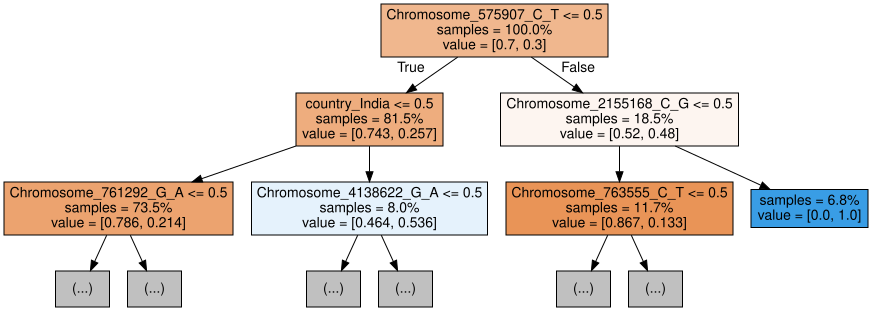

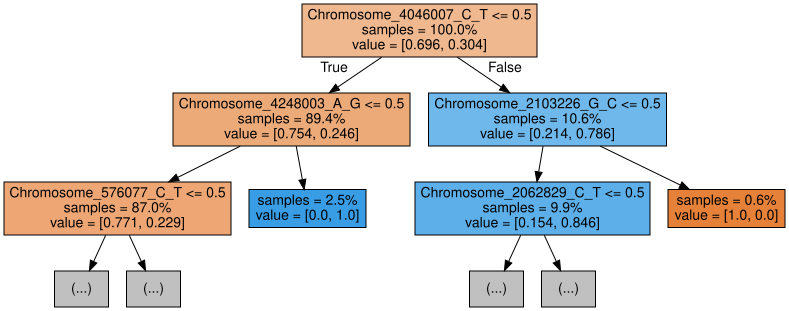

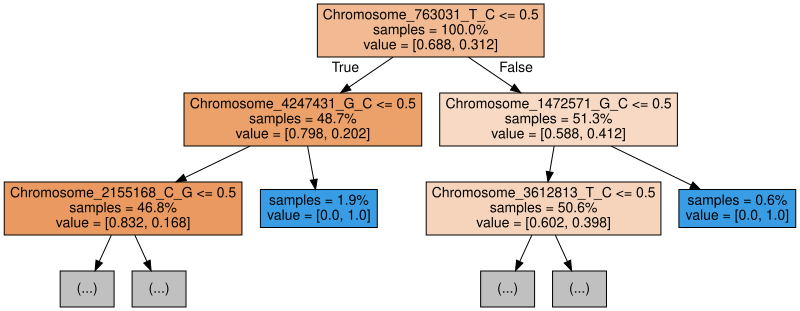

In [52]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_{i}", format="png", cleanup=True)

#### Feature importance

In [55]:
importances = rf.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(fi_df)

                     Feature  Importance
689   Chromosome_2155168_C_G    0.161935
269    Chromosome_761155_C_T    0.056898
582   Chromosome_1673425_C_T    0.054636
400    Chromosome_781687_A_G    0.031155
1438  Chromosome_4247429_A_G    0.027141
...                      ...         ...
978   Chromosome_2997858_T_G    0.000000
979   Chromosome_2997944_C_T    0.000000
983   Chromosome_3064889_T_C    0.000000
984   Chromosome_3064953_G_A    0.000000
863   Chromosome_2290199_G_C    0.000000

[1726 rows x 2 columns]


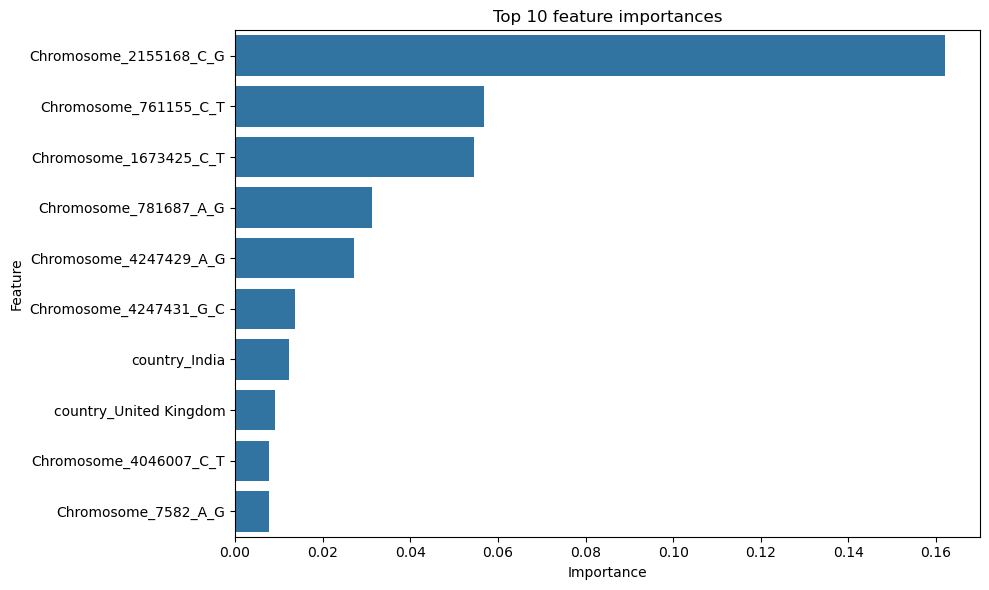

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(10))
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()

In [59]:
threshold = 1e-3
near_zero_fi = fi_df[fi_df['Importance'] < threshold]['Feature'].tolist()
print(f"{len(near_zero_fi)} features have importance < {threshold}")

1513 features have importance < 0.001


**note to self: find recommended threshold (rrl)**

#### Hyperparameter Tuning

Source: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

In [64]:
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Estimator: RandomForestClassifier(max_depth=30, min_samples_split=5, n_estimators=300)


In [65]:
grid_search.fit(X_train, y_train)
updated_model = grid_search.best_estimator_
y_pred = updated_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.87        38
           1       1.00      0.59      0.74        27

    accuracy                           0.83        65
   macro avg       0.89      0.80      0.81        65
weighted avg       0.87      0.83      0.82        65



In [66]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [300, 500, 800, 1000, 1200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

random_search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_distributions, cv=5)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)

Best Parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}
Best Estimator: RandomForestClassifier(max_depth=20, n_estimators=800)


In [67]:
random_search.fit(X_train, y_train)
updated_model = random_search.best_estimator_
y_pred = updated_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.87        38
           1       1.00      0.59      0.74        27

    accuracy                           0.83        65
   macro avg       0.89      0.80      0.81        65
weighted avg       0.87      0.83      0.82        65



### Rifampicin resistance prediction

In [69]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

RIF_na = input_df['rifampicin_resistance'].isna().sum()
print("Missing values before drop:", RIF_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['rifampicin_resistance'])

Missing values before drop: 55


In [70]:
columns_to_drop = ['isoniazid_resistance', 'pyrazinamide_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['rifampicin_resistance'] = input_df['rifampicin_resistance'].astype(int)

In [71]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 1712)


#### Training

In [73]:
X = input_df.drop('rifampicin_resistance', axis=1)

# one-hot encoding country column
X = pd.get_dummies(X, columns=['country'])
y = input_df['rifampicin_resistance']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Shape of X (features): (325, 1725)
Shape of y (target): (325,)


In [74]:
print("Training feature shape:", X_train.shape)
print("Training label shape:", y_train.shape)
print("Testing feature shape:", X_test.shape)
print("Testing label shape:", y_test.shape)

Training feature shape: (260, 1725)
Training label shape: (260,)
Testing feature shape: (65, 1725)
Testing label shape: (65,)


In [75]:
rf = RandomForestClassifier(random_state=42)  
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [76]:
y_pred = rf.predict(X_test)

#### Performance metrics

In [77]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9384615384615385


In [78]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9333333333333333


In [79]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.8235294117647058


In [80]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.875


In [81]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[47  1]
 [ 3 14]]


#### Tree visualization

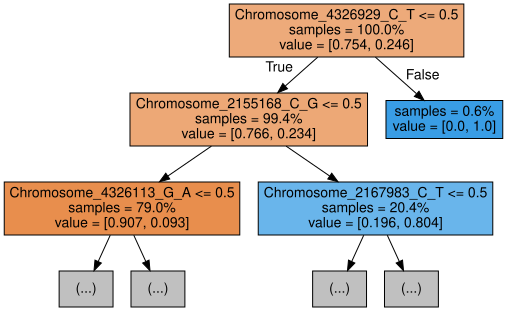

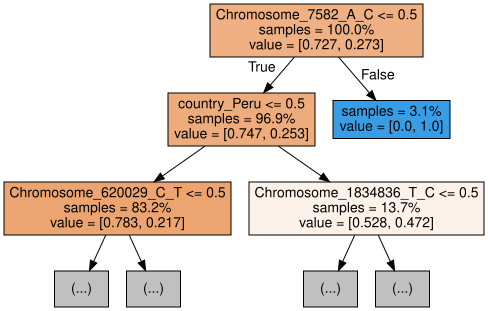

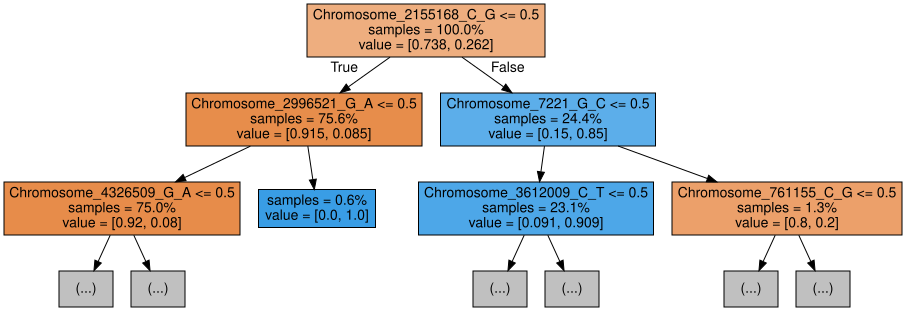

In [83]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_{i}", format="png", cleanup=True)

## Pyrazinmide Resistance

In [125]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

PZA_na = input_df['pyrazinamide_resistance'].isna().sum()
print("Missing values before drop:", PZA_na)

Missing values before drop: 131


majority are missing - skipping

## Streptomycin Resistance

In [127]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['streptomycin_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

Missing values before drop: 127


majority are missing - skipping

<h4><center>END</center></h4>